# Tennessee Eastman Process — Modellbildung

Lädt die Rohdaten `data_train`/`data_test`/`data_error` aus *tep_generation*, trainiert/lädt ein MLP auf den stationären Trainingsphasen, wertet den Prädiktionsfehler auf Test- und Fehlerfalldaten aus und speichert die gescorten Artefakte `data_scored_test`/`data_scored_error` für *tep_detection* und *tep_adaptation*.

In [ ]:
FORCE_RECOMPUTE = False
IS_FINAL = True 

In [ ]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
model_dir = base_dir / "models"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for _d in (data_dir, model_dir, plot_dir, results_dir):
    os.makedirs(_d, exist_ok=True) 

In [56]:
import numpy as np

In [57]:
# --- Konstanten ---
RUN_ID = "58a387b8" # None

SEED = 42

ERROR_VARIANT = {"idv": 29, "amp": 1.0}   # None -> neuester Fehlerfall
WINDOW_SIZE = 10
ARCH = [5, 5, 1]
ACT = "tanh"
EPOCHS = 200
BATCH = 200
PATIENCE = 20
VAL_SPLIT = 0.15

SAMPLES_PER_H = 20
DRIFT_PERIOD, DRIFT_GAMMA, DRIFT_SEED = 800.0, 0.2, 42   # wie in temexd_mod.c
PLOT_FRAC = 0.1              # Anteil geplotteter Punkte
PLOT_YLIM = (-1e2, 1e2)      # symlog-Bereich der Fehlerachse
PLOT_EPOCH = "1970-01-01"    # Zeitstempel-Ursprung wie im synthetischen Fall

rng = np.random.default_rng(SEED)


## Daten laden

In [58]:
import run_registry as rr
data_store = rr.tep_data_store(data_dir)
model_store = rr.tep_model_store(model_dir)
plot_store = rr.tep_plot_store(plot_dir)
res_store = rr.tep_results_store(results_dir)

run_id = data_store.latest_id("data_train") if RUN_ID is None else RUN_ID
if run_id is None:
    raise FileNotFoundError("Kein train-Artefakt. Bitte tep_generation.ipynb ausfuehren.")
train_data = data_store.load("data_train", run_id=run_id, rename=True)
run_cfg = dict(train_data.attrs.get("config", train_data.attrs))
cfg = rr.RunConfig(run_cfg)

ramp_duration = run_cfg["ramp_h"]
soak_time = run_cfg["soak_h"]
test_split = run_cfg["test_split"]

test_data = data_store.load("data_test", cfg, rename=True)

# Fehlerfall: eigene Kennung aus Basis + error-Sektion. Mit ERROR_VARIANT wird sie
# direkt berechnet, ohne Vorgabe das neueste Artefakt genommen und geprueft.
error_data, error_cfg = rr.load_section(data_store, "data_error", cfg, "error",
                                        ERROR_VARIANT)
error_variant = error_cfg.sections["error"]
ERROR_VARIANT_ID = error_variant["idv"]
print(f"run_id = {run_id} | error_run_id = {error_cfg.id} "
      f"(IDV {ERROR_VARIANT_ID}, amp {error_variant['amp']})")

run_id = 58a387b8 | error_run_id = fedcacf7 (IDV 29, amp 1.0)


## Pre-processing

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def drop_outliers(df: pd.DataFrame, z_thresh: float=3.0) -> pd.DataFrame:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    z_scores = np.abs((df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std())
    df_out = df.copy()
    for col in numeric_cols:
        outlier_idx = z_scores[col] >= z_thresh
        df_out.loc[outlier_idx, col] = df[col].mean()
    return df_out

Drop outliers

In [60]:
unchanged_columns = [c for c in train_data.columns if c in ["mode", "original_index", "reset", "status", "time"] or c.startswith("IDV")]
train_outliers_droped = drop_outliers(train_data.drop(columns=unchanged_columns))

Initialize scaler

In [61]:
scaler = MinMaxScaler()
train_scaled_array = scaler.fit_transform(train_outliers_droped)
train_scaled_data = pd.DataFrame(train_scaled_array, columns=train_outliers_droped.columns, index=train_outliers_droped.index)

Rolling mean

In [62]:
train_smoothed_data = train_scaled_data.rolling(window=WINDOW_SIZE, min_periods=1).mean()
train_smoothed_data[unchanged_columns] = train_data[unchanged_columns]

Select stationary operations

In [63]:
n = 5
num_cols = train_data.select_dtypes(include="number").columns
candidates = [c for c in num_cols if c not in ["time", "original_index", "Scenario", "mode", "cost"] and not c.endswith("SP")]
top_n_by_var = train_data[candidates].var().sort_values(ascending=False).head(n).index.tolist()
top_n_by_var

['E Feed',
 'D Feed',
 'Stripper Pressure',
 'Reactor Pressure',
 'Product Sep Pressure']

In [64]:
from scipy.stats import linregress

def window_slope(y:np.ndarray):
    x = np.arange(len(y))
    return linregress(x, y).slope

def mark_consecutive_trues(s:pd.Series, min_len:int):
    return (s.groupby(by=(s != s.shift()).cumsum()).transform('size') >= min_len) * s

def steady_mask(df: pd.DataFrame, win:int, slope_thr:float, min_len: int, offset: int=0):
    roll = df.rolling(win)
    slopes = roll.apply(window_slope, raw=True)
    summed_slopes = slopes.abs().sum(axis=1)
    stationarity = summed_slopes.abs() < slope_thr
    stationarity = mark_consecutive_trues(stationarity, min_len)
    stationarity.iloc[offset:win] = False
    return summed_slopes, stationarity

In [65]:
def static_steady_mask(df: pd.DataFrame, ramp_duration: float, soak_time: float):
    mask = pd.Series(False, index=df.index)
    for mode in df["mode"].unique():
        mode_data = df[df["mode"] == mode]
        start_time = mode_data["time"].min() + ramp_duration
        end_time = start_time + soak_time - ramp_duration
        mask.loc[mode_data[(mode_data["time"] >= start_time) & (mode_data["time"] <= end_time)].index] = True

    return mask

In [66]:
train_slopes, train_stationary_mask = steady_mask(train_smoothed_data.loc[:,top_n_by_var], 50, 0.00045, 200, 25)

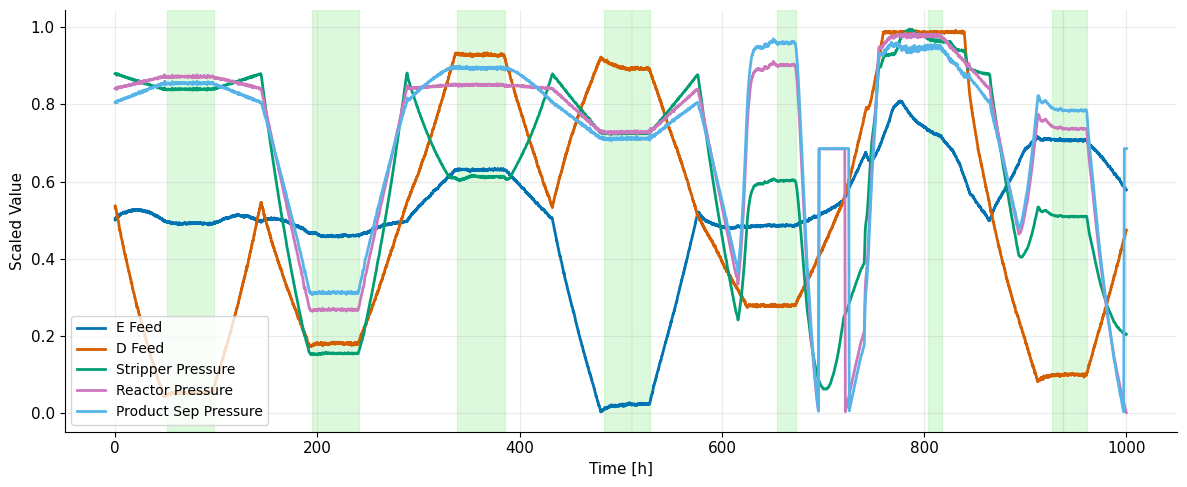

In [67]:
import matplotlib.pyplot as plt

filter_start = 0
filter_end = 20000

x_axis = train_smoothed_data["original_index"][filter_start:filter_end] / 20

plt.figure(figsize=(12, 5))
for col in top_n_by_var:
    plt.plot(x_axis, train_smoothed_data[filter_start:filter_end][col], label=col)
plt.xlabel("Time [h]")

in_stationary = False
start_idx = None
for i, val in enumerate(train_stationary_mask[filter_start:filter_end]):
    if val and not in_stationary:
        in_stationary = True
        start_idx = i
    elif not val and in_stationary:
        in_stationary = False
        end_idx = i
        plt.axvspan(x_axis.iloc[start_idx], x_axis.iloc[end_idx-1], color='lightgreen', alpha=0.3)
if in_stationary:
    plt.axvspan(x_axis.iloc[start_idx], x_axis.iloc[-1], color='lightgreen', alpha=0.3)
plt.ylabel("Scaled Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
print("Number of steady points detected:", train_stationary_mask.sum())

Number of steady points detected: 21101


In [69]:
def find_stationary_ranges(df_smoothed, stationary_mask, same_length:bool=True):
    stationary_changes = stationary_mask.astype(int).diff().fillna(0)
    starts = df_smoothed.index[stationary_changes == 1]
    ends = df_smoothed.index[stationary_changes == -1]

    # Edge cases
    if df_smoothed.index[stationary_mask][0] == df_smoothed.index[0]:
        starts = starts.insert(0, df_smoothed.index[0])
    if df_smoothed.index[stationary_mask][-1] == df_smoothed.index[-1]:
        ends = ends.append(pd.Index([df_smoothed.index[-1]]))

    stationary_ranges = list(zip(starts, ends))
    if not same_length:
        return stationary_ranges
    else:
        min_duration = min([end - start for start, end in stationary_ranges])
        stationary_ranges = [(start, start + min_duration) for start, end in stationary_ranges]
        return stationary_ranges

In [70]:
train_stationary_ranges = find_stationary_ranges(train_smoothed_data, train_stationary_mask, same_length=False)

In [71]:
stationary_means = pd.concat([train_smoothed_data.loc[(train_smoothed_data["original_index"]>=start) & 
                                      (train_smoothed_data["original_index"]<=end),:].mean(axis=0) 
                                      for start, end in train_stationary_ranges], axis=1).T

c:\git\process_optimization_concept_drift\venv_37\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  This is separate from the ipykernel package so we can avoid doing imports until


In [72]:
labels_for_costs = [
    'Component A in Purge',
    'Component C in Purge',
    'Component D in Purge',
    'Component E in Purge',
    'Component F in Purge',
    'Component G in Purge',
    'Component H in Purge',
    'Purge Rate',
    'Component D in Product',
    'Component E in Product',
    'Component F in Product',
    'Product Sep Underflow',
    'Compressor Work',
    'Stripper Steam Flow'
]
unchanged_setpoints = [
    'StripLevelSP', 
    'SepLevelSP', 
    'ReactorLevelSP', 
    'ReactorPressSP', 
    'SteamValvePosSP', 
    'AgitatorSpeedSP'
]

In [73]:
import seaborn as sns

corr = stationary_means.corr()

setpoint_labels_update = [col for col in stationary_means.columns if col not in unchanged_setpoints and col not in labels_for_costs]
main_corr = corr.loc["cost", setpoint_labels_update].abs().sort_values(ascending=False)
main_corr.head(15)

cost                          1
Purge valve              0.7651
A feed load              0.7428
A Feed                   0.7427
Component B to Reactor   0.7015
E Feed                   0.6214
E feed load              0.6214
Component B in Purge     0.5986
ProductionSP             0.4601
Separator liquid load    0.4115
Stripper Underflow       0.4108
Stripper Temp             0.396
MolePctGSP               0.3847
Component G in Product   0.3841
Reactor Level            0.3825
Name: cost, dtype: float64

## Heatmap

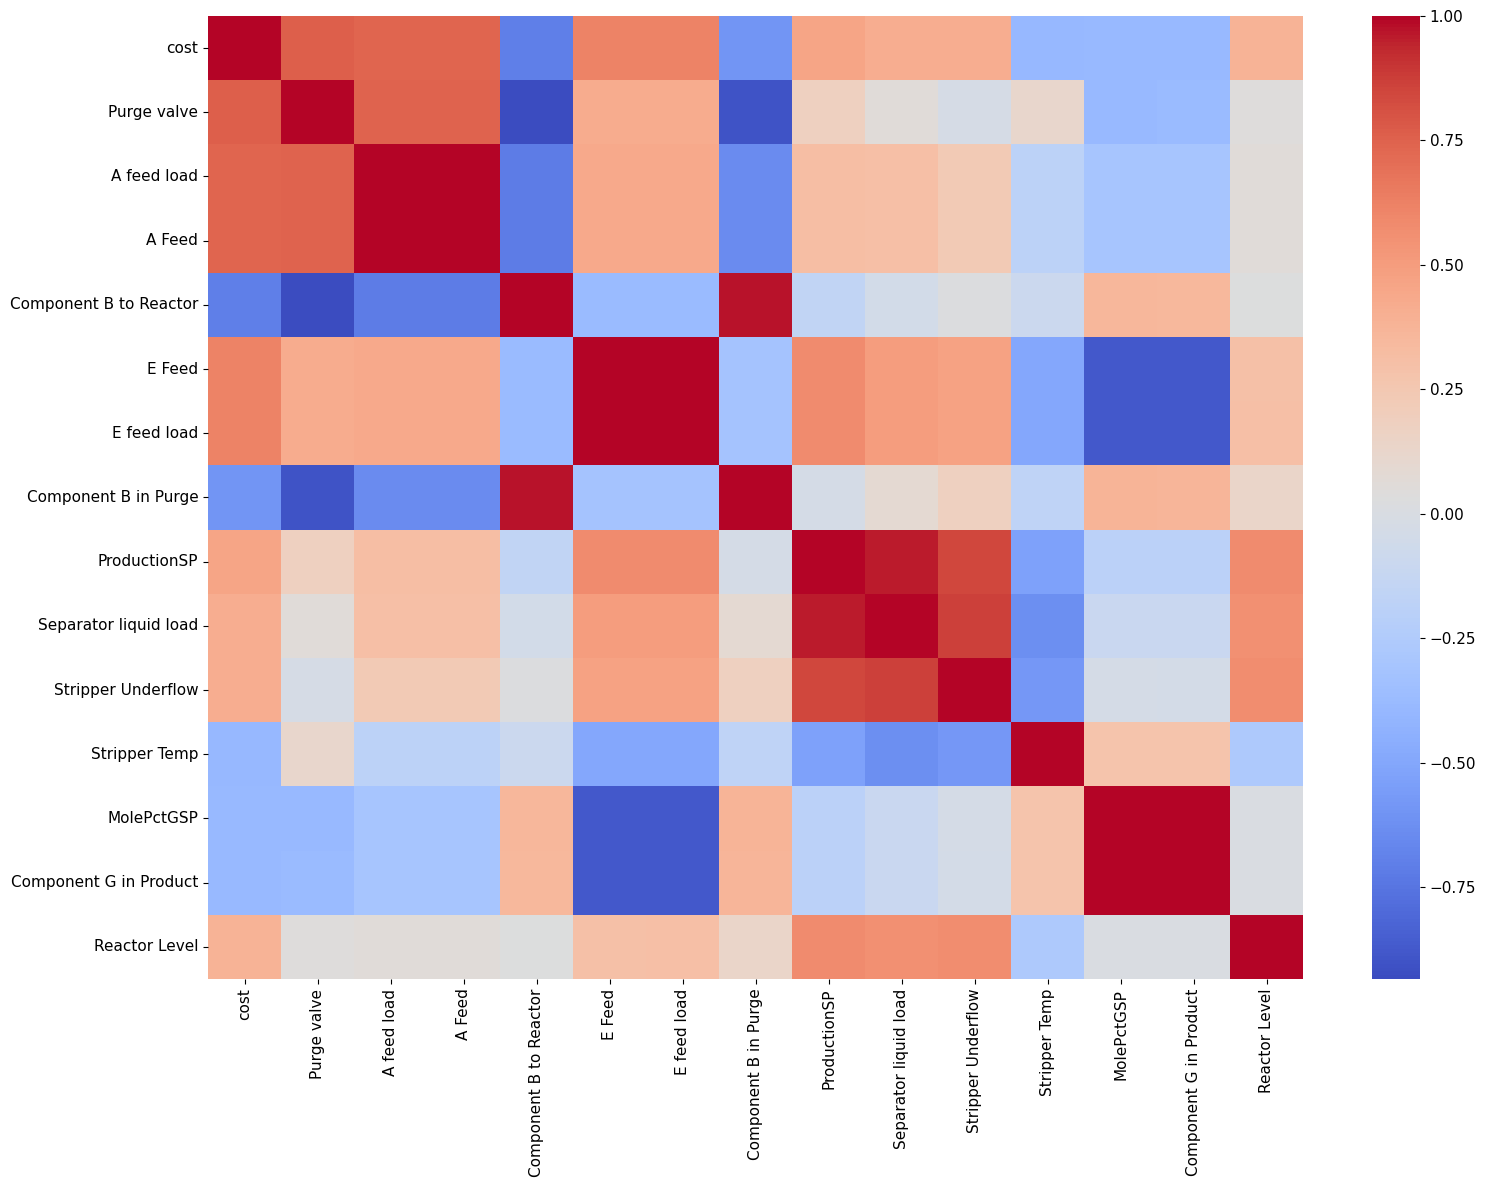

In [74]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr.loc[main_corr[:15].index, main_corr[:15].index], cmap="coolwarm", annot=False, fmt=".2f")
plt.tight_layout()
plt.show()

Prepare training

In [75]:
feature_cols = main_corr.iloc[1:8].index
excluded_cols = ["Stripper Temp", "Product Sep Temp"]
feature_cols = [col for col in feature_cols if col not in labels_for_costs and col not in excluded_cols]
len(feature_cols), feature_cols

(7,
 ['Purge valve',
  'A feed load',
  'A Feed',
  'Component B to Reactor',
  'E Feed',
  'E feed load',
  'Component B in Purge'])

In [76]:
train_stationary_only = True

if train_stationary_only:
    train_preprocessed_data = pd.concat([train_smoothed_data.loc[(train_smoothed_data["original_index"]>=start) & 
                                      (train_smoothed_data["original_index"]<=end),:]
                                      for start, end in train_stationary_ranges])
else:
    train_preprocessed_data = train_smoothed_data.copy()

In [77]:
from sklearn.model_selection import train_test_split

val_split = 0.15

x_temp = train_preprocessed_data.loc[:, feature_cols].values
y_temp = train_preprocessed_data.loc[:, "cost"].values

x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=val_split, random_state=SEED)

print(f"Train shape: {x_train.shape}, {y_train.shape}")
print(f"Validation shape: {x_val.shape}, {y_val.shape}")

Train shape: (17961, 7), (17961,)
Validation shape: (3170, 7), (3170,)


## Train Neural network

In [78]:
model_params = {"arch": ARCH, "act": ACT, "opt": "adam", "epochs": EPOCHS,
                "batch": BATCH, "patience": PATIENCE, "val_split": VAL_SPLIT,
                "seed": SEED, "window_size": WINDOW_SIZE, "features": list(feature_cols)}

model_cfg = cfg.compose(model=model_params)
scored_error_cfg = model_cfg.compose(error=error_variant)

_model_loaded_from_cache = model_store.exists("model", model_cfg) and not FORCE_RECOMPUTE

# Einmalige Uebernahme des Altbestands (frueher model_cfg + variant-Token).
# Nach dem ersten erfolgreichen Lauf kann dieser Block entfallen.
if not data_store.exists("data_scored_error", scored_error_cfg) \
        and data_store.exists("data_scored_error", model_cfg, variant=error_variant):
    data_store.save(data_store.load("data_scored_error", model_cfg, variant=error_variant, rename=True),
                    "data_scored_error", scored_error_cfg)
    print(f"data_scored_error aus Altbestand uebernommen -> {scored_error_cfg.id}")

_scored_loaded_from_cache = (
    data_store.exists("data_scored_test", model_cfg)
    and data_store.exists("data_scored_error", scored_error_cfg)
    and not FORCE_RECOMPUTE
)

In [79]:
if _model_loaded_from_cache:
    _mc = model_store.load("model", model_cfg, rename=True)
    model, feature_cols = _mc["model"], _mc["feature_cols"]
else:
    import tensorflow as tf
    from tensorflow import keras
    from keras import layers
    from keras.callbacks import EarlyStopping

    tf.keras.utils.set_random_seed(SEED)

    model = keras.Sequential([
        layers.Dense(ARCH[0], activation=ACT, input_shape=(len(feature_cols),)),
        layers.Dense(ARCH[1], activation=ACT), 
        layers.Dense(ARCH[2])
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)

    history = model.fit(
        x_train, y_train, 
        validation_data=(x_val, y_val),
        epochs=EPOCHS, 
        batch_size=BATCH, 
        callbacks=[early_stop], 
        verbose=1
    )
    model_store.save({"model": model, "feature_cols": list(feature_cols), "window_size": WINDOW_SIZE},
               "model", model_cfg)

Epoch 1/200
90/90 [==============================] - 1s 4ms/step - loss: 0.0587 - mae: 0.2050 - val_loss: 0.0375 - val_mae: 0.1672
Epoch 2/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0257 - mae: 0.1337 - val_loss: 0.0149 - val_mae: 0.0947
Epoch 3/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0114 - mae: 0.0794 - val_loss: 0.0103 - val_mae: 0.0735
Epoch 4/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0102 - mae: 0.0724 - val_loss: 0.0101 - val_mae: 0.0714
Epoch 5/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0100 - mae: 0.0708 - val_loss: 0.0100 - val_mae: 0.0699
Epoch 6/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0099 - mae: 0.0695 - val_loss: 0.0098 - val_mae: 0.0693
Epoch 7/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0098 - mae: 0.0686 - val_loss: 0.0097 - val_mae: 0.0694
Epoch 8/200
90/90 [==============================] - 0s 2ms/step - loss: 0.0097 - m

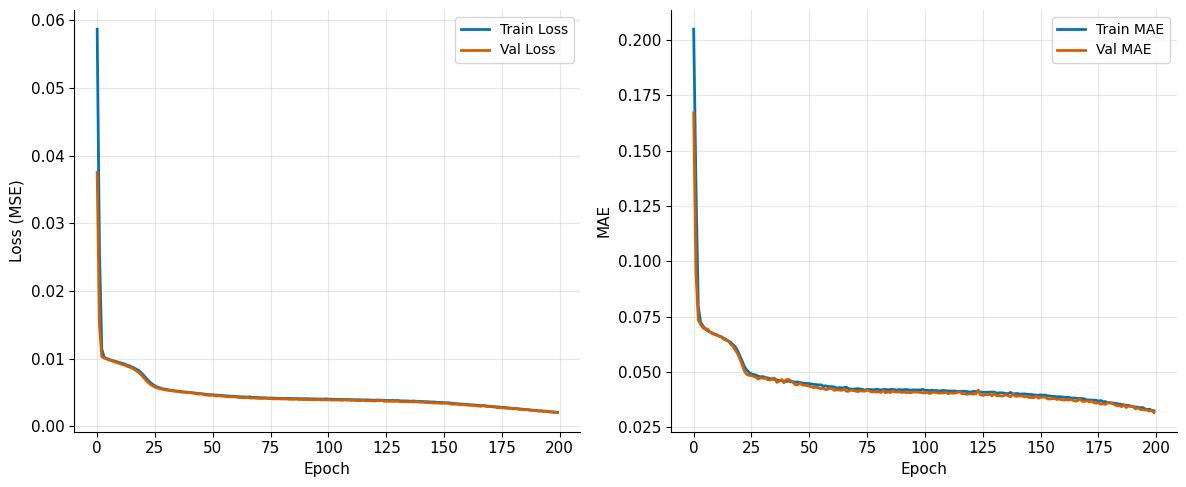

In [80]:
if not _model_loaded_from_cache:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Preprocess test data

Wird uebersprungen und aus dem Cache geladen, falls `data_scored_test` fuer diese `model_cfg` bereits existiert (analog zum Modell-Cache).

In [81]:
if _scored_loaded_from_cache:
    test_preprocessed_data = data_store.load("data_scored_test", model_cfg, rename=True)
    print(f"Scored-Testdaten aus Cache geladen ({len(test_preprocessed_data)} Zeilen)")

In [82]:
if not _scored_loaded_from_cache:
    test_outliers_droped = drop_outliers(test_data.drop(columns=unchanged_columns))

In [83]:
if not _scored_loaded_from_cache:
    test_scaled_array = scaler.transform(test_outliers_droped)
    test_scaled_data = pd.DataFrame(test_scaled_array, columns=test_outliers_droped.columns, index=test_outliers_droped.index)

In [84]:
if not _scored_loaded_from_cache:
    test_smoothed_data = test_scaled_data.rolling(window=WINDOW_SIZE, min_periods=1).mean()
    test_smoothed_data[unchanged_columns] = test_data[unchanged_columns]

In [85]:
if not _scored_loaded_from_cache:
    test_stationary_mask = static_steady_mask(test_smoothed_data, ramp_duration, soak_time)
    test_stationary_ranges = find_stationary_ranges(test_smoothed_data, test_stationary_mask, same_length=False)

In [86]:
if not _scored_loaded_from_cache:
    test_stationary_only = False

    if test_stationary_only:
        test_preprocessed_data = pd.concat([test_smoothed_data.loc[(test_smoothed_data["original_index"]>=start) & 
                                          (test_smoothed_data["original_index"]<=end),:]
                                          for start, end in test_stationary_ranges])
    else:
        test_preprocessed_data = test_smoothed_data.copy()

Add model predictions and model error to test data

In [87]:
if not _scored_loaded_from_cache:
    test_features = test_preprocessed_data[feature_cols].to_numpy(dtype="float32", copy=False)
    y_pred = model.predict(test_features)

    test_preprocessed_data.loc[:, "y_pred"] = y_pred
    test_preprocessed_data.loc[:, "model_error"] = test_preprocessed_data["y_pred"] - test_preprocessed_data["cost"]

    test_preprocessed_data.set_index("original_index", inplace=True)

2491/2491 [==============================] - 3s 981us/step


In [88]:
if not _scored_loaded_from_cache:
    test_reset_indices = test_smoothed_data[test_smoothed_data["reset"] == True].index

In [89]:
if not _scored_loaded_from_cache:
    test_reset_indices

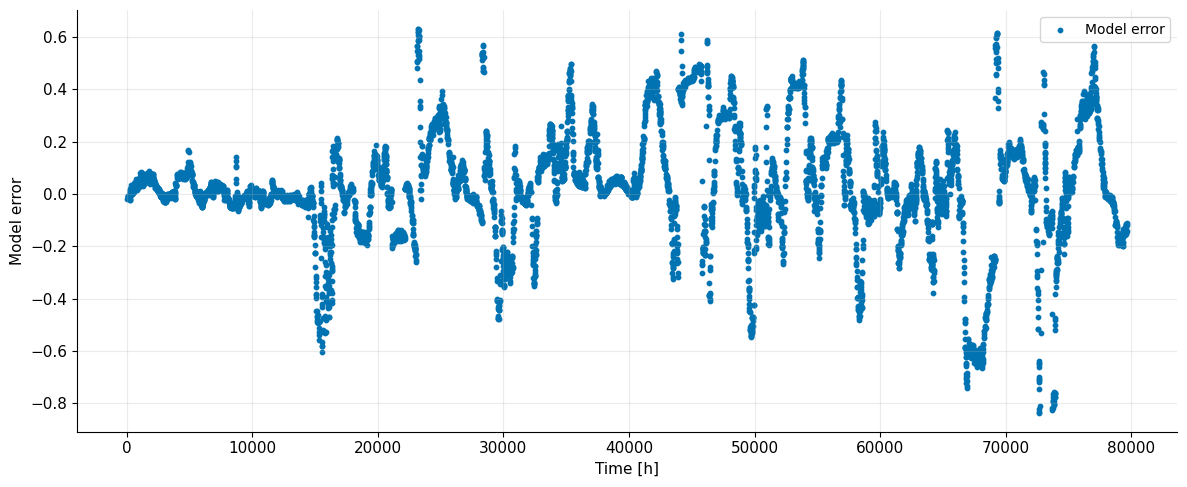

In [90]:
if not _scored_loaded_from_cache:
    test_data_sampled = test_preprocessed_data.sample(frac=.1, random_state=SEED)

    plt.figure(figsize=(12, 5))
    plt.scatter(test_data_sampled.index, test_data_sampled["model_error"], label="Model error", s=10)

    for i, reset_idx in enumerate(test_reset_indices):
        plt.axvline(reset_idx, color='red', linestyle='--', alpha=0.6, label='reset' if i == 0 else "")

    plt.xlabel("Time [h]")
    plt.ylabel("Model error")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [91]:
if not _scored_loaded_from_cache:
    data_store.save(test_preprocessed_data, "data_scored_test", model_cfg,
               meta={"feature_cols": list(feature_cols),
                     "stationary_ranges": [(int(s), int(e)) for s, e in test_stationary_ranges]})

## Preprocess error data

Wird uebersprungen und aus dem Cache geladen, falls `data_scored_error` fuer diese `model_cfg` bereits existiert.

In [92]:
if _scored_loaded_from_cache:
    error_preprocessed_data = data_store.load("data_scored_error", scored_error_cfg, rename=True)
    print(f"Scored-Fehlerdaten aus Cache geladen ({len(error_preprocessed_data)} Zeilen)")

In [93]:
if not _scored_loaded_from_cache:
    error_outliers_droped = drop_outliers(error_data.drop(columns=unchanged_columns))

In [94]:
if not _scored_loaded_from_cache:
    error_scaled_array = scaler.transform(error_outliers_droped)
    error_scaled_data = pd.DataFrame(error_scaled_array, columns=error_outliers_droped.columns, index=error_outliers_droped.index)

In [95]:
if not _scored_loaded_from_cache:
    error_smoothed_data = error_scaled_data.rolling(window=WINDOW_SIZE, min_periods=1).mean()
    error_smoothed_data[unchanged_columns] = error_data[unchanged_columns]

In [96]:
if not _scored_loaded_from_cache:
    error_slopes, error_stationary_mask = steady_mask(error_smoothed_data.loc[:,top_n_by_var], 50, 0.00045, 200, 25)
    error_stationary_ranges = find_stationary_ranges(error_smoothed_data, error_stationary_mask, same_length=False)

In [97]:
if not _scored_loaded_from_cache:
    error_stationary_only = test_stationary_only

    if error_stationary_only:
        error_preprocessed_data = pd.concat([error_smoothed_data.loc[(error_smoothed_data["original_index"]>=start) & 
                                          (error_smoothed_data["original_index"]<=end),:]
                                          for start, end in test_stationary_ranges])
    else:
        error_preprocessed_data = error_smoothed_data.copy()

Add model predictions and model error to error data

In [98]:
if not _scored_loaded_from_cache:
    error_features = error_preprocessed_data[feature_cols].to_numpy(dtype="float32", copy=False)
    y_pred = model.predict(error_features)

    error_preprocessed_data.loc[:, "y_pred"] = y_pred
    error_preprocessed_data.loc[:, "model_error"] = error_preprocessed_data["y_pred"] - error_preprocessed_data["cost"]

    error_preprocessed_data.set_index("original_index", inplace=True)

2320/2320 [==============================] - 2s 1ms/step


In [99]:
if not _scored_loaded_from_cache:
    error_reset_indices = error_smoothed_data[error_smoothed_data["reset"] == True].index

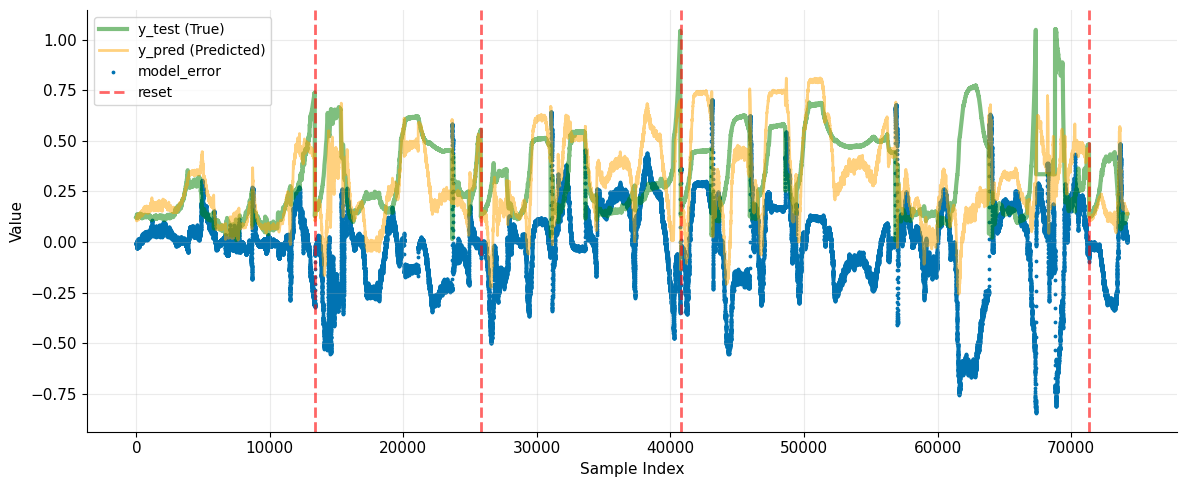

In [100]:
if not _scored_loaded_from_cache:
    plt.figure(figsize=(12, 5))
    plt.plot(error_preprocessed_data["cost"], label="y_test (True)", alpha=0.5, linewidth=3, color="green")
    plt.plot(error_preprocessed_data["y_pred"], label="y_pred (Predicted)", alpha=0.5, color="orange")
    plt.scatter(error_preprocessed_data.index, error_preprocessed_data["model_error"], label="model_error", s=3)

    for i, reset_idx in enumerate(error_reset_indices):
        plt.axvline(reset_idx, color='red', linestyle='--', alpha=0.6, label='reset' if i == 0 else "")

    plt.xlabel("Sample Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [101]:
if not _scored_loaded_from_cache:
    data_store.save(error_preprocessed_data, "data_scored_error", scored_error_cfg)

## Vergleich Modellfehler: nominal vs. Fehlerfall

Stellt den Modellfehler des nominalen Testlaufs und des Fehlerfalls modeweise gegenüber,
normiert beide mit Mittelwert und Streuung des nominalen Testfehlers (identisch zu
*tep_detection*) und legt das rekonstruierte Driftsignal $c(t)$ auf die zweite Ordinate.

In [102]:
# Modellfehler modeweise gegenueberstellen. Die Simulationszeit des Fehlerlaufs
# wird mitgefuehrt, da sie das Argument des Driftsignals ist (sie beginnt nach
# jedem Reset wieder bei 0, wie drift_tonset in temexd_mod.c).
combined = []

for mode in test_preprocessed_data["mode"].unique():
    test_temp = (test_preprocessed_data.loc[test_preprocessed_data["mode"] == mode,
                                            ["model_error"]]
                 .reset_index(drop=True))
    fault_temp = (error_preprocessed_data.loc[error_preprocessed_data["mode"] == mode,
                                              ["model_error", "time", "reset"]]
                  .reset_index(drop=True))
    combined.append(pd.concat([test_temp, fault_temp], axis=1))

combined_data = pd.concat(combined, axis=0, ignore_index=True)
combined_data.columns = ["model_error_normal", "model_error_fault",
                         "time_fault", "reset_fault"]


### Fehler normieren

Der Modellfehler wird mit Mittelwert und Streuung des nominalen Testfehlers normiert,
damit die Ordinate dieselbe Bedeutung hat wie im synthetischen Fall und in *tep_detection*.

In [103]:
_err_free = test_preprocessed_data["model_error"].to_numpy(dtype=float)
NORM_MEAN = float(np.nanmean(_err_free))
NORM_STD = float(np.nanstd(_err_free)) or 1.0

for _c in ("normal", "fault"):
    combined_data[f"error_norm_{_c}"] = (
        (combined_data[f"model_error_{_c}"] - NORM_MEAN) / NORM_STD)

# Darstellungszeit als Zeitstempel (analog syn_generation): der Strom ist eine
# Zeitreihe, die Achse traegt Monatsticks. Davon unabhaengig ist "time_fault",
# die Simulationszeit je Lauf, die das Driftsignal argumentiert.
t_h = combined_data.index.to_numpy(dtype=float) / SAMPLES_PER_H
plot_index = pd.to_datetime(t_h * 3600.0, unit="s", origin=pd.Timestamp(PLOT_EPOCH))

_z = combined_data[["error_norm_normal", "error_norm_fault"]].to_numpy(dtype=float)
print(f"{len(combined_data)} Zeitschritte ({t_h[-1]:.0f} h, bis {plot_index[-1]:%d.%m.%Y}) | "
      f"Normierung: mean={NORM_MEAN:.4g}, std={NORM_STD:.4g}")
print(f"Norm. Fehler: max|z|={np.nanmax(np.abs(_z)):.1f}, "
      f"99.9%-Quantil={np.nanquantile(np.abs(_z), 0.999):.1f} "
      f"-> PLOT_YLIM ggf. anpassen")


80645 Zeitschritte (4032 h, bis 18.06.1970) | Normierung: mean=0.02628, std=0.2176
Norm. Fehler: max|z|=4.0, 99.9%-Quantil=3.8 -> PLOT_YLIM ggf. anpassen


### Driftsignal rekonstruieren

Python-Port von `drift_function_sawtooth.c` (bitidentisch, splitmix64) mit den Parametern
aus `temexd_mod.c` (Periode 800 h, $\gamma = 0{,}2$, Seed 42). Die Funktion ist zustandslos,
der Verlauf hängt nur von der Simulationszeit seit Drift-Aktivierung ab und ist damit
vollständig reproduzierbar.

In [104]:
_M64 = (1 << 64) - 1
CD_MID, CD_HALF = 0.0, 0.5   # Spiegel der #defines in drift_function_sawtooth.c


def _drift_rand(seed, idx):
    z = (seed + idx * 0x9E3779B97F4A7C15) & _M64
    z = ((z ^ (z >> 30)) * 0xBF58476D1CE4E5B9) & _M64
    z = ((z ^ (z >> 27)) * 0x94D049BB133111EB) & _M64
    z = z ^ (z >> 31)
    return (z >> 11) / 9007199254740992.0


def _drift_uniform(seed, idx, lo, hi):
    return lo + (hi - lo) * _drift_rand(seed, idx)


def _drift_boundary(k, period, gamma, seed):
    if k <= 0:
        return 0.0
    return k * period + (2.0 * _drift_rand(seed, 1000 + k) - 1.0) * gamma * 0.5 * period


def drift_signal(t, period=DRIFT_PERIOD, gamma=DRIFT_GAMMA, seed=DRIFT_SEED):
    if t <= 0.0 or period <= 0.0:
        return 0.0
    k = int(np.floor(t / period))
    while k > 0 and t < _drift_boundary(k, period, gamma, seed):
        k -= 1
    while t >= _drift_boundary(k + 1, period, gamma, seed):
        k += 1
    t0 = _drift_boundary(k, period, gamma, seed)
    t1 = _drift_boundary(k + 1, period, gamma, seed)
    c0 = CD_MID if k == 0 else _drift_uniform(seed, 2000 + k,
                                              CD_MID + CD_HALF / 4.0, CD_MID + CD_HALF)
    c1 = _drift_uniform(seed, 3000 + k, CD_MID - CD_HALF, CD_MID - CD_HALF / 4.0)
    return c0 + (c1 - c0) * (t - t0) / (t1 - t0)


_t_fault = combined_data["time_fault"].to_numpy(dtype=float)
cd_signal = np.array([error_variant["amp"] * drift_signal(t) if np.isfinite(t) else np.nan
                      for t in _t_fault])
print(f"Driftsignal: min={np.nanmin(cd_signal):.3f}, max={np.nanmax(cd_signal):.3f} | "
      f"Kinetikfaktor 1+c in [{1 + np.nanmin(cd_signal):.2f}, {1 + np.nanmax(cd_signal):.2f}] | "
      f"erste Segmentgrenze bei {_drift_boundary(1, DRIFT_PERIOD, DRIFT_GAMMA, DRIFT_SEED):.0f} h")


Driftsignal: min=-0.441, max=0.256 | Kinetikfaktor 1+c in [0.56, 1.26] | erste Segmentgrenze bei 773 h


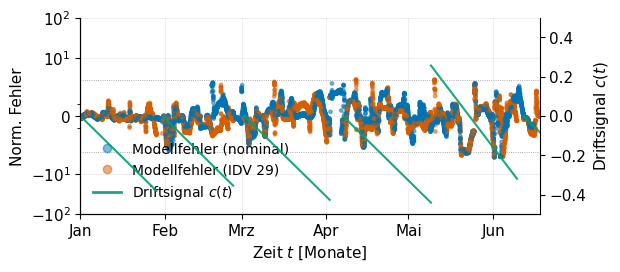

In [105]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

rng_plot = np.random.default_rng(SEED)

fig, ax, ax2 = ts.error_timeseries(
    plot_index,
    [(combined_data["error_norm_normal"].to_numpy(dtype=float),
      "drift_free", "Modellfehler (nominal)"),
     (combined_data["error_norm_fault"].to_numpy(dtype=float),
      "drift_afflicted", f"Modellfehler (IDV {ERROR_VARIANT_ID})")],
    cd=cd_signal,
    ylabel="Norm. Fehler",
    xlabel="Zeit $t$ [Monate]",
    cd_label="Driftsignal $c(t)$",
    ylim=PLOT_YLIM, cd_amp=0.5, cd_tick_step=0.2,
    frac=PLOT_FRAC, rng=rng_plot, height_scale=0.45,
    legend=dict(loc="lower left", markerscale=1),
)
fig.tight_layout()
plot_store.save_figure(fig, "error", scored_error_cfg, final=IS_FINAL,
                       savefig_kwargs={"dpi": 300}, archive_kwargs={"dpi": 300})
plt.show()


## Numerische Auswertung der Modelldegradation

In [106]:
r0 = test_preprocessed_data["model_error"].to_numpy(dtype=float)
r1 = error_preprocessed_data["model_error"].to_numpy(dtype=float)

stats = pd.DataFrame({
    "MLP": dict(
        rmse_free=np.sqrt(np.nanmean(r0**2)),
        rmse_fault=np.sqrt(np.nanmean(r1**2)),
        std_free=np.nanstd(r0),
        bias_fault=np.nanmean(r1),
        std_fault=np.nanstd(r1),
    )
}).T
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
print(stats.to_string())

     bias_fault  rmse_fault  rmse_free  std_fault  std_free
MLP    -0.01659      0.2058     0.2192     0.2051    0.2176


## Ergebnisse speichern

In [107]:
from src.utils import results_export as rx

_keys = [(k, k, "num") for k in
         ["rmse_free", "rmse_fault", "std_free", "bias_fault", "std_fault"]]

(rx.ResultDoc()
   .integer("n_test", len(test_preprocessed_data))
   .integer("n_error", len(error_preprocessed_data))
   .stats(stats, _keys, into="models")
   .save(res_store, "error", scored_error_cfg, final=IS_FINAL))

Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_error.json


'C:\\git\\process_optimization_concept_drift\\results\\tep_error.json'

In [108]:
def _de(x, nd):
    if x is None or (isinstance(x, float) and x != x):
        return "--"
    return f"{x:.{nd}f}".replace(".", "{,}")

_keys = [("rmse_free", "RmseFree", 3), ("rmse_fault", "RmseFault", 3),
         ("std_free", "SigmaFree", 3), ("bias_fault", "Bias", 3), ("std_fault", "Sigma", 3)]
_lines = ["% automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren"]
for m in stats.index:
    for col, suf, nd in _keys:
        _lines.append(rf"\newcommand{{\tepstat{m}{suf}}}{{{_de(stats.loc[m, col], nd)}}}")
_tex = "\n".join(_lines) + "\n"
_pt, _ = res_store.save_text(_tex, "tep_model_error_stats", scored_error_cfg, final=IS_FINAL)
print(f"LaTeX-Makros -> {_pt}\n")
print(_tex)

LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_tep_model_error_stats.tex

% automatisch erzeugt aus tep_model.ipynb - nicht manuell editieren
\newcommand{\tepstatMLPRmseFree}{0{,}219}
\newcommand{\tepstatMLPRmseFault}{0{,}206}
\newcommand{\tepstatMLPSigmaFree}{0{,}218}
\newcommand{\tepstatMLPBias}{-0{,}017}
\newcommand{\tepstatMLPSigma}{0{,}205}



## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [109]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Modellbildung beendet.\n"
    f"Model Run-ID: {model_cfg.id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}): {scored_error_cfg.id}",
    copy_value=model_cfg.id,
)


--- Lauf abgeschlossen ---
Modellbildung beendet.
Model Run-ID: 5c05391e
Fehlerfall (IDV 29): 3d66ecaf

